In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import sys

sys.path.insert(0, "/home/joshua/PhD_year_1/jaxsp/Adding_stellar_masses")


import bessel_test as BT

import analytic_test as AT

import analytic_test_gaunt as ATG

import jaxsp as jsp

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]
[CudaDevice(id=0)]


# Using analytic method - either Gaunt coeffs or using s2fft

## 1) Static, spherically symmetric profile using ias15 - 100 timesteps

In [3]:

import importlib
importlib.reload(ATG)


animate = False
static = True
frozen = False
SphHT = False
integrator = 'ias15'
plot = True

frozen_test_analytic = ATG.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 10, no_time_steps = 50, total_evolve_time = 5, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, static = static, frozen = frozen, SphHT = SphHT, integrator = integrator, plot = plot, animate=animate, animate_every=10)

[CudaDevice(id=0)]
[CudaDevice(id=0)]


l max from jaxsp: 23
Total enclosed mass at rmax: 6.640e+02
Total mass from wavefunction: 7.164e+02
Scaling density and mass by factor 1.078988260895345 to match total mass
Particle 0: v_circ = 3.435 km/s
Particle 1: v_circ = 3.098 km/s
Particle 2: v_circ = 3.440 km/s
Particle 3: v_circ = 3.882 km/s
Particle 4: v_circ = 3.167 km/s
Particle 5: v_circ = 3.623 km/s
Particle 6: v_circ = 3.519 km/s
Particle 7: v_circ = 3.851 km/s
Particle 8: v_circ = 3.966 km/s
Particle 9: v_circ = 3.644 km/s
Loading Gaunt table from gaunt_lmax23_Lout47.npz ...


yt : [INFO     ] 2026-04-08 12:20:40,281 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-04-08 12:20:40,283 Parameters: domain_dimensions         = [1000 1000 1000]
yt : [INFO     ] 2026-04-08 12:20:40,288 Parameters: domain_left_edge          = [-440.90838429 -440.90838429 -440.90838429]
yt : [INFO     ] 2026-04-08 12:20:40,289 Parameters: domain_right_edge         = [440.90838429 440.90838429 440.90838429]
yt : [INFO     ] 2026-04-08 12:20:40,289 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-04-08 12:20:40,493 Rendering scene (Can take a while).
yt : [INFO     ] 2026-04-08 12:20:40,508 Creating volume


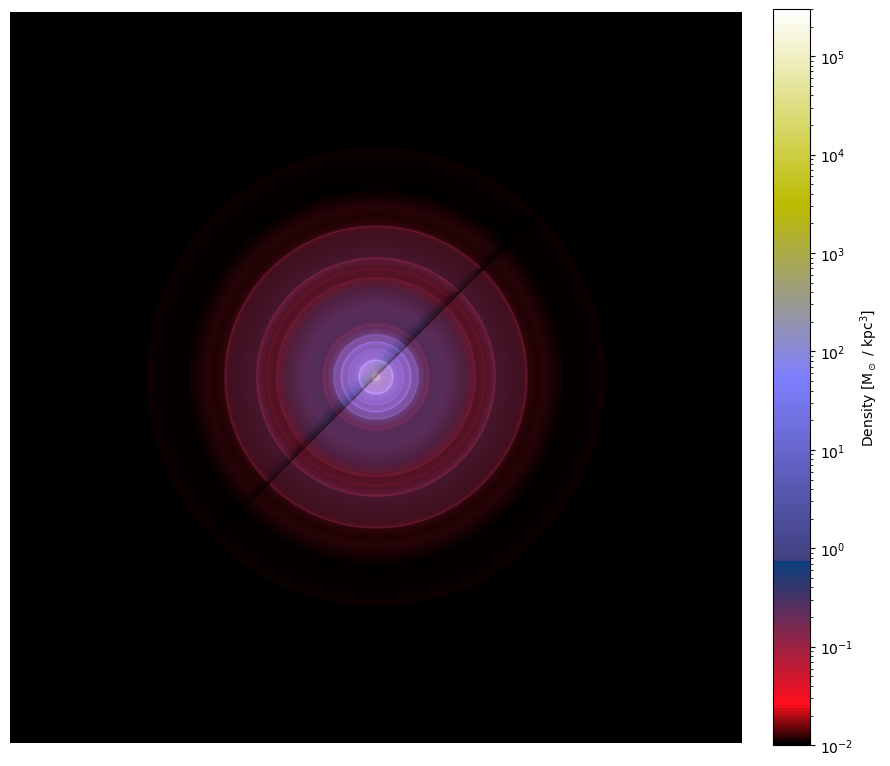

Time step 1 / 50
  Force calls this timestep: 142
Time stepping all particles completed in 39.76 seconds
Time step 2 / 50


KeyboardInterrupt: 

In [4]:

frozen_test_analytic.run_simulation()

In [26]:
# Convert to numpy for plotting/analysis
import numpy as np

positions_all = np.array([p.positions_xyz for p in frozen_test_analytic.particles])  # (N_particles, N_steps+1, 3)
r_all         = np.array([p.r_values      for p in frozen_test_analytic.particles])  # (N_particles, N_steps+1)
v_disp_all    = np.array([p.stellar_v_disp for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1)
kinetic_energy_all = np.array([p.kinetic_energy for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1)
potential_energy_all = np.array([p.potential_energy for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1)
ang_mom_all = np.array([p.ang_mom for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1, 3)

(10, 51, 3)


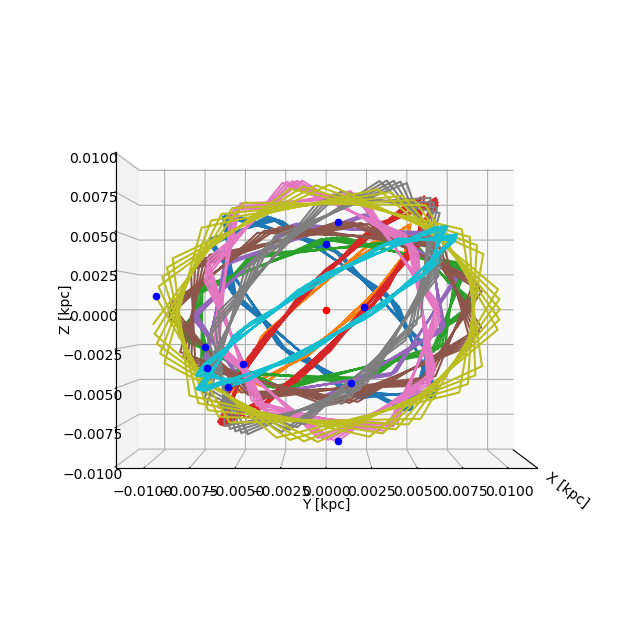

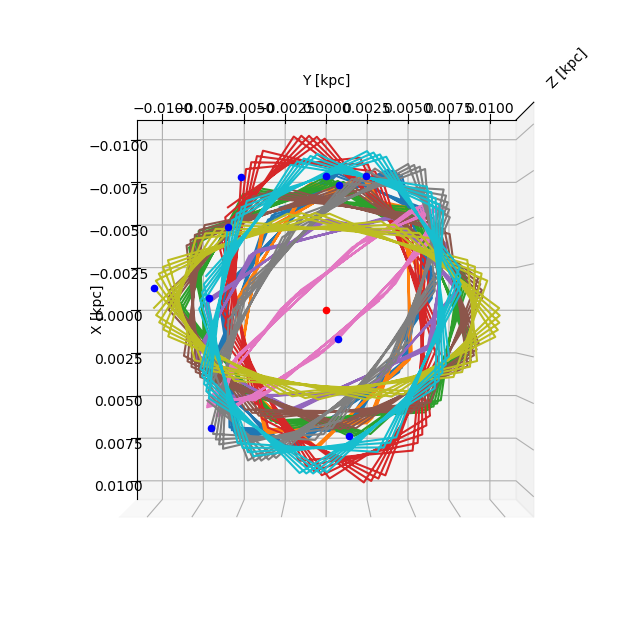

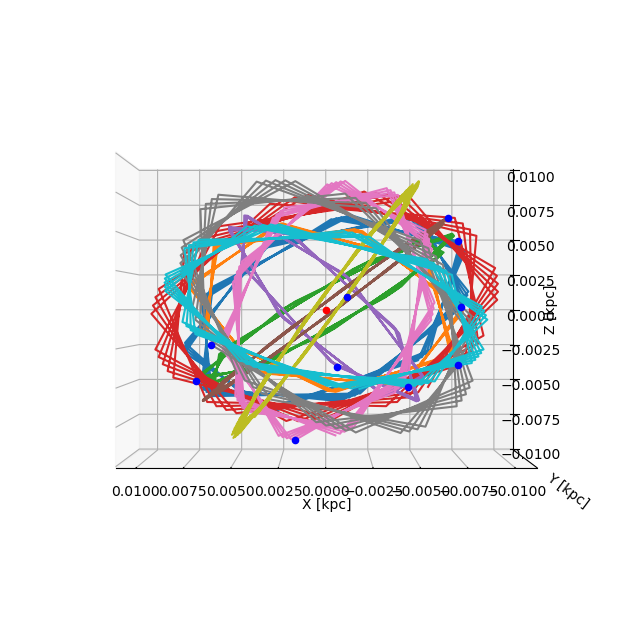

In [27]:

print(positions_all.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


In [8]:
if animate == True:
    ani = frozen_test_analytic.animator.create_animation()


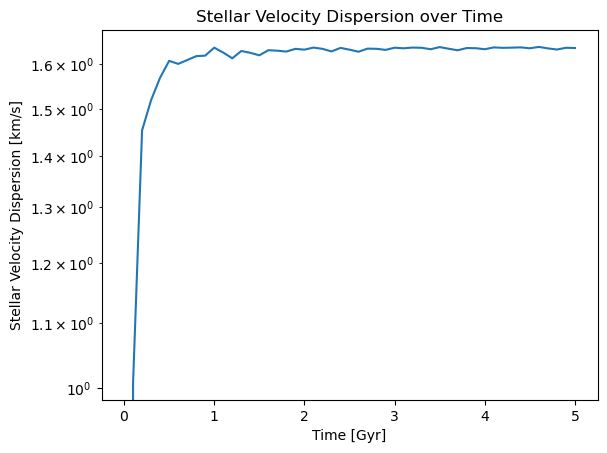

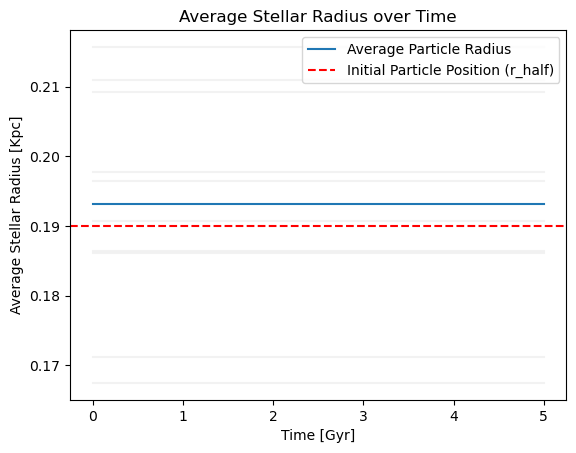

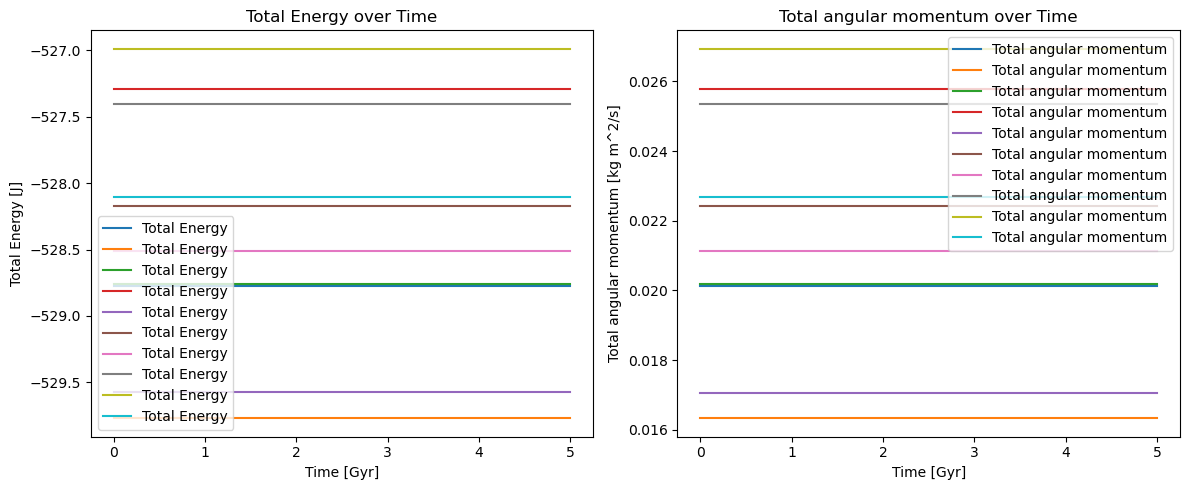

In [ ]:
time_step2 = frozen_test_analytic.time_step
stellar_v_disp2 = np.mean(v_disp_all, axis=0)  # Average over particles

average_r2 = np.mean(r_all, axis=0)  # Average over particles


x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, stellar_v_disp2 * frozen_test_analytic.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, average_r2 * frozen_test_analytic.u.to_Kpc, label='Average Particle Radius')
for particle in range(r_all.shape[0]):
    plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, r_all[particle] * frozen_test_analytic.u.to_Kpc, alpha = 0.1, color='gray')
plt.axhline(frozen_test_analytic.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for particle in range(ang_mom_all.shape[0]):
    ax[0].plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, (kinetic_energy_all[particle] + potential_energy_all[particle]), label='Total Energy')
ax[0].set_xlabel('Time [Gyr]')
ax[0].set_ylabel('Total Energy [J]')
ax[0].set_title('Total Energy over Time')




for particle in range(ang_mom_all.shape[0]):
    ax[1].plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, ang_mom_all[particle], label='Total angular momentum')
ax[1].set_xlabel('Time [Gyr]')
ax[1].set_ylabel('Total angular momentum [kg m^2/s]')
ax[1].set_title('Total angular momentum over Time')


plt.tight_layout()
plt.show()




# 2) Static with leapfrog - 1000 timesteps

In [1]:

import importlib
importlib.reload(ATG)


animate = False
static = True
frozen = False
SphHT = False
integrator = 'leapfrog'

frozen_test_analytic = ATG.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 10, no_time_steps = 1000, total_evolve_time = 5, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, static = static, frozen = frozen, SphHT = SphHT, integrator = integrator, animate=animate, animate_every=10)

NameError: name 'ATG' is not defined

In [2]:

frozen_test_analytic.run_simulation()

NameError: name 'frozen_test_analytic' is not defined

In [ ]:
# Convert to numpy for plotting/analysis
import numpy as np

positions_all = np.array([p.positions_xyz for p in frozen_test_analytic.particles])  # (N_particles, N_steps+1, 3)
r_all         = np.array([p.r_values      for p in frozen_test_analytic.particles])  # (N_particles, N_steps+1)
v_disp_all    = np.array([p.stellar_v_disp for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1)
kinetic_energy_all = np.array([p.kinetic_energy for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1)
potential_energy_all = np.array([p.potential_energy for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1)
ang_mom_all = np.array([p.ang_mom for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1, 3)

(10, 101, 3)


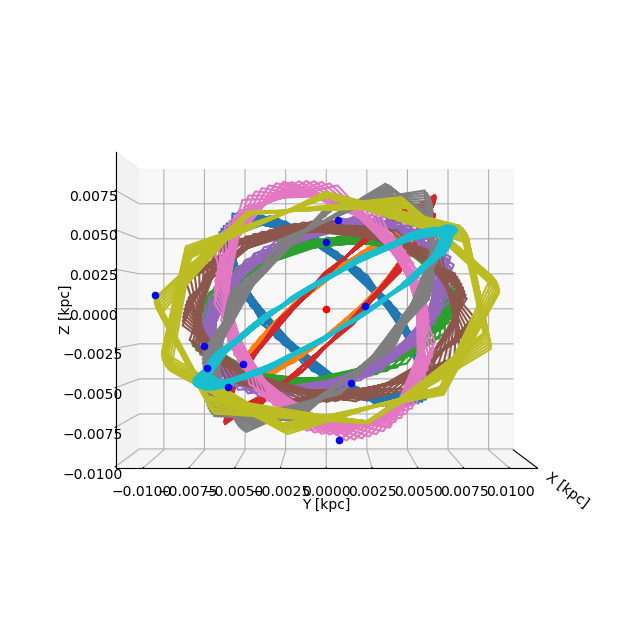

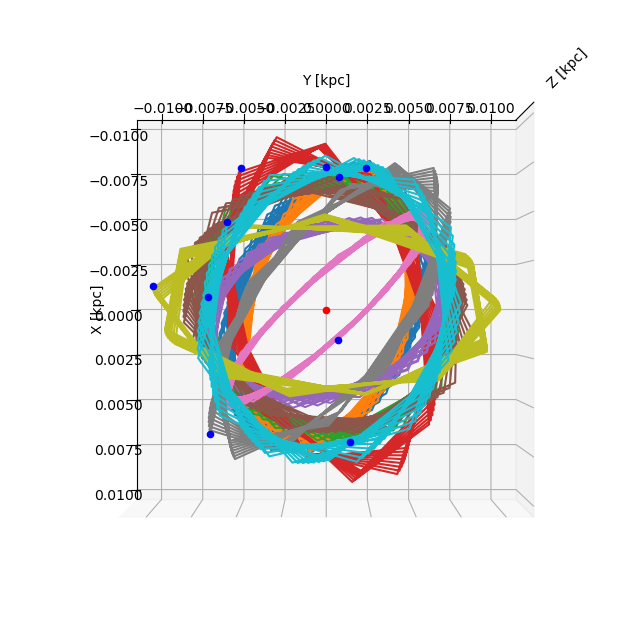

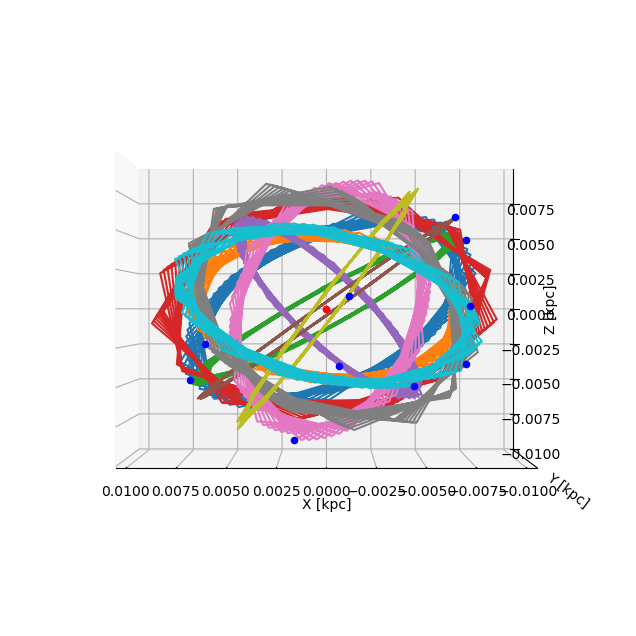

In [19]:

print(positions_all.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


In [20]:
if animate == True:
    ani = frozen_test_analytic.animator.create_animation()


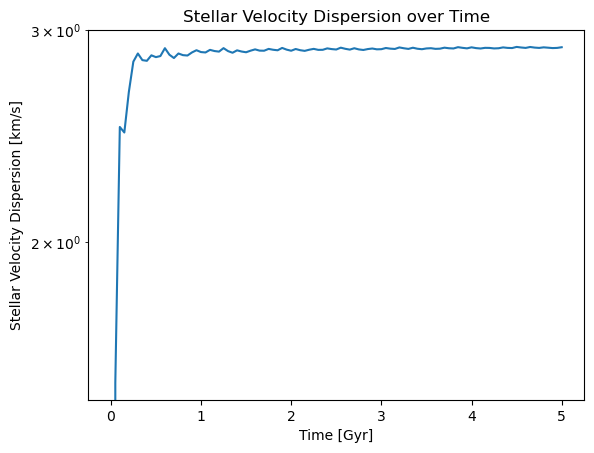

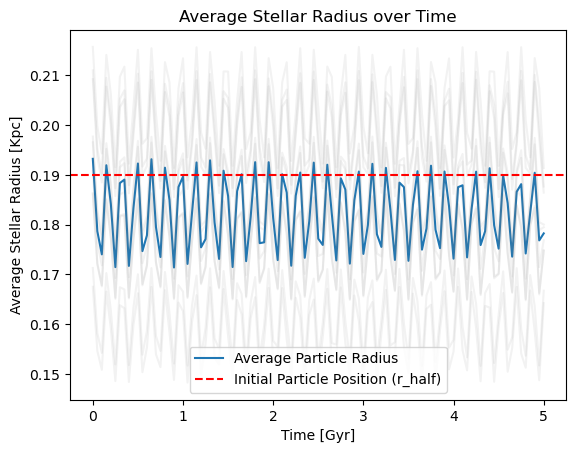

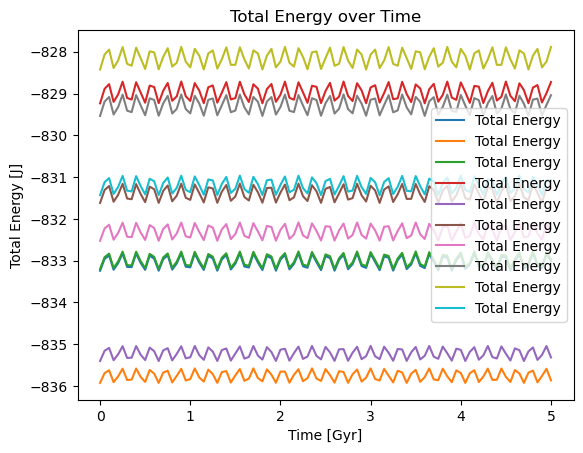

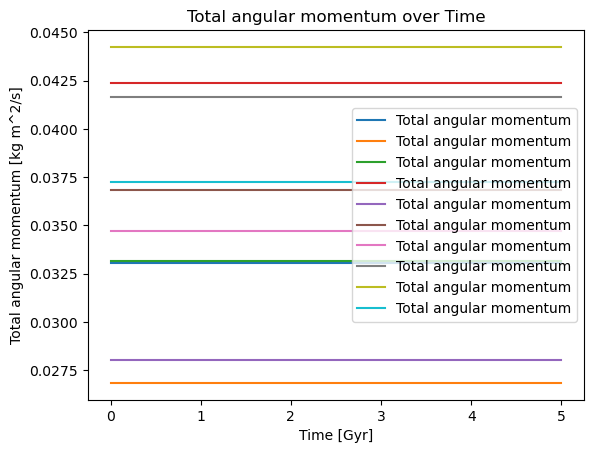

In [ ]:
time_step2 = frozen_test_analytic.time_step
stellar_v_disp2 = np.mean(v_disp_all, axis=0)  # Average over particles

average_r2 = np.mean(r_all, axis=0)  # Average over particles


x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, stellar_v_disp2 * frozen_test_analytic.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, average_r2 * frozen_test_analytic.u.to_Kpc, label='Average Particle Radius')
for particle in range(r_all.shape[0]):
    plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, r_all[particle] * frozen_test_analytic.u.to_Kpc, alpha = 0.1, color='gray')
plt.axhline(frozen_test_analytic.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for particle in range(ang_mom_all.shape[0]):
    ax[0].plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, (kinetic_energy_all[particle] + potential_energy_all[particle]), label='Total Energy')
ax[0].set_xlabel('Time [Gyr]')
ax[0].set_ylabel('Total Energy [J]')
ax[0].set_title('Total Energy over Time')


for particle in range(ang_mom_all.shape[0]):
    ax[1].plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, ang_mom_all[particle], label='Total angular momentum')
ax[1].set_xlabel('Time [Gyr]')
ax[1].set_ylabel('Total angular momentum [kg m^2/s]')
ax[1].set_title('Total angular momentum over Time')


plt.tight_layout()
plt.show()




# 3) Frozen ULDM with ias15 - 100 timesteps

In [6]:

import importlib
importlib.reload(ATG)


animate = False
static = False
frozen = True
SphHT = False
integrator = 'ias15'

frozen_test_analytic = ATG.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 10, no_time_steps = 50, total_evolve_time = 5, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, static = static, frozen = frozen, SphHT = SphHT, integrator = integrator, animate=animate, animate_every=10)

[CpuDevice(id=0)]
[CpuDevice(id=0)]


l max from jaxsp: 23


yt : [INFO     ] 2026-04-02 13:39:59,176 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-04-02 13:39:59,179 Parameters: domain_dimensions         = [1000 1000 1000]
yt : [INFO     ] 2026-04-02 13:39:59,179 Parameters: domain_left_edge          = [-440.90838429 -440.90838429 -440.90838429]
yt : [INFO     ] 2026-04-02 13:39:59,181 Parameters: domain_right_edge         = [440.90838429 440.90838429 440.90838429]
yt : [INFO     ] 2026-04-02 13:39:59,181 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-04-02 13:39:59,405 Rendering scene (Can take a while).
yt : [INFO     ] 2026-04-02 13:40:00,153 Creating volume


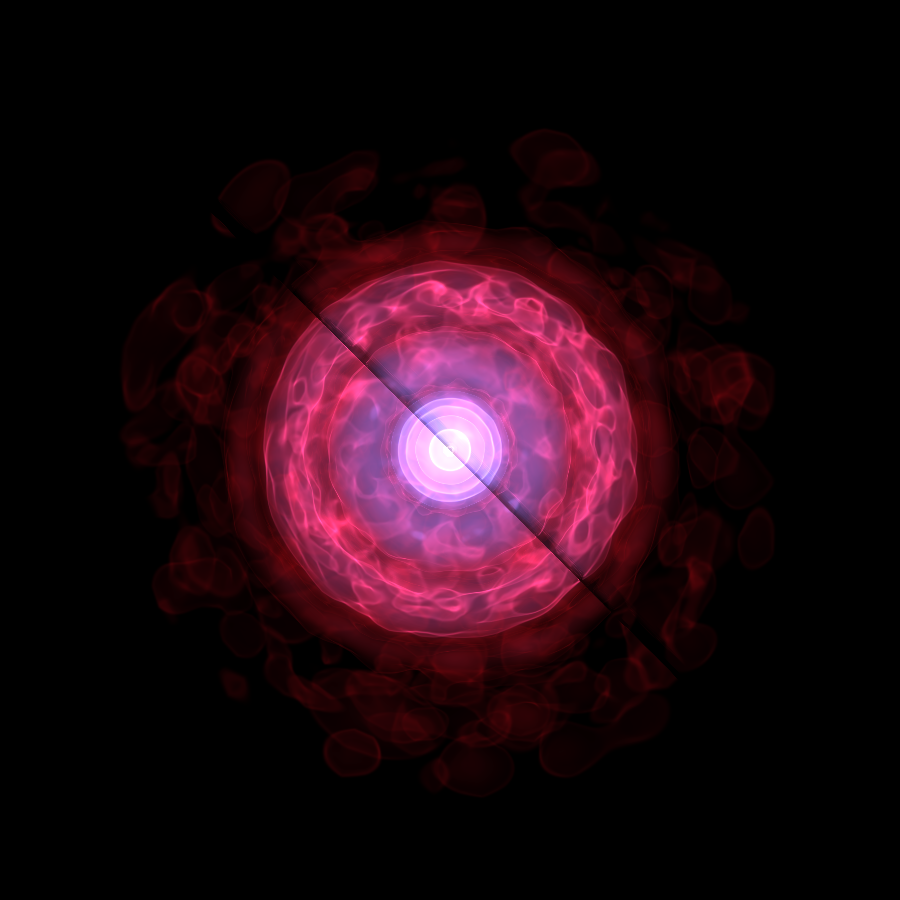

Total enclosed mass at rmax: 6.640e+02
Total mass from wavefunction: 7.164e+02
Scaling density and mass by factor 1.0789882227257153 to match total mass
Particle 0: v_circ = 3.434 km/s
Particle 1: v_circ = 3.098 km/s
Particle 2: v_circ = 3.439 km/s
Particle 3: v_circ = 3.882 km/s
Particle 4: v_circ = 3.166 km/s
Particle 5: v_circ = 3.622 km/s
Particle 6: v_circ = 3.519 km/s
Particle 7: v_circ = 3.850 km/s
Particle 8: v_circ = 3.966 km/s
Particle 9: v_circ = 3.643 km/s
Loading Gaunt table from gaunt_lmax23_Lout47.npz ...
Time step 1 / 50


KeyboardInterrupt: 

In [7]:

frozen_test_analytic.run_simulation()

In [31]:
# Convert to numpy for plotting/analysis
import numpy as np

positions_all = np.array([p.positions_xyz for p in frozen_test_analytic.particles])  # (N_particles, N_steps+1, 3)
r_all         = np.array([p.r_values      for p in frozen_test_analytic.particles])  # (N_particles, N_steps+1)
v_disp_all    = np.array([p.stellar_v_disp for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1)
kinetic_energy_all = np.array([p.kinetic_energy for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1)
potential_energy_all = np.array([p.potential_energy for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1)
ang_mom_all = np.array([p.ang_mom for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1, 3)

(10, 51, 3)


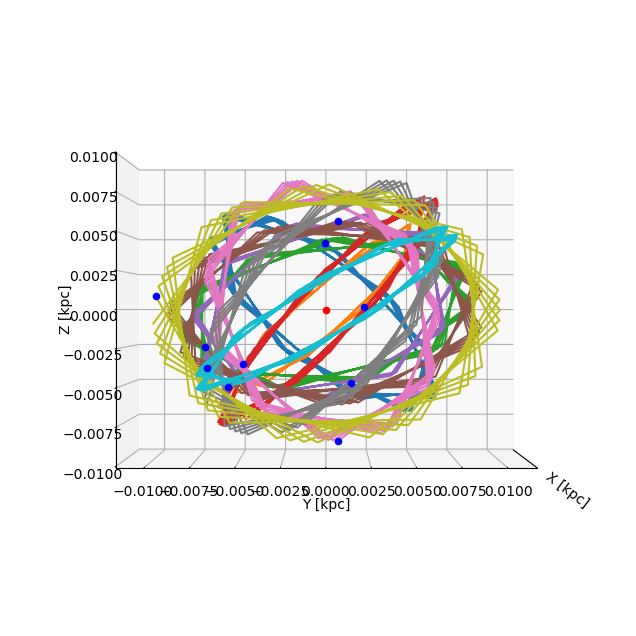

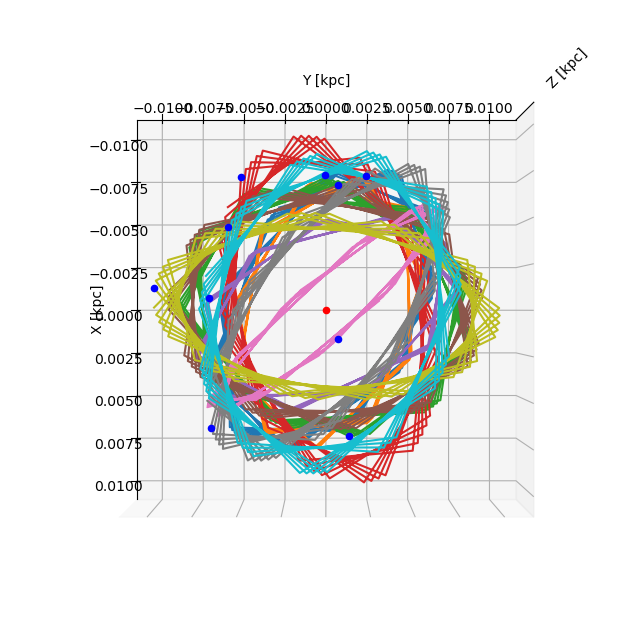

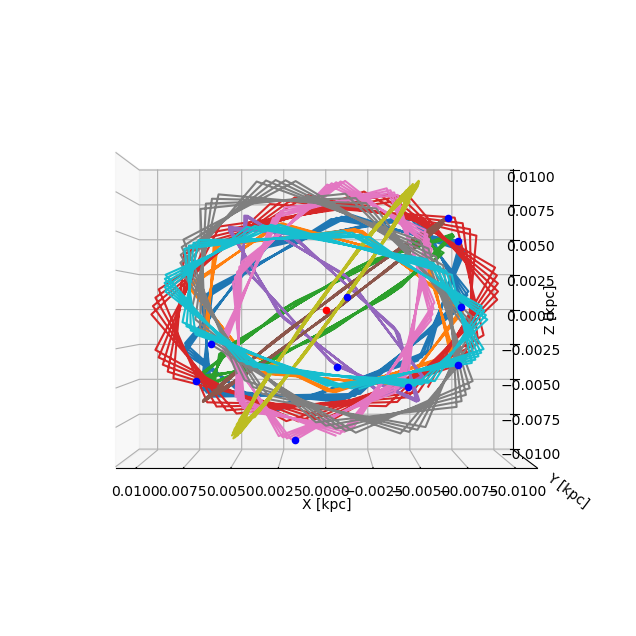

In [32]:

print(positions_all.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


In [33]:
if animate == True:
    ani = frozen_test_analytic.animator.create_animation()


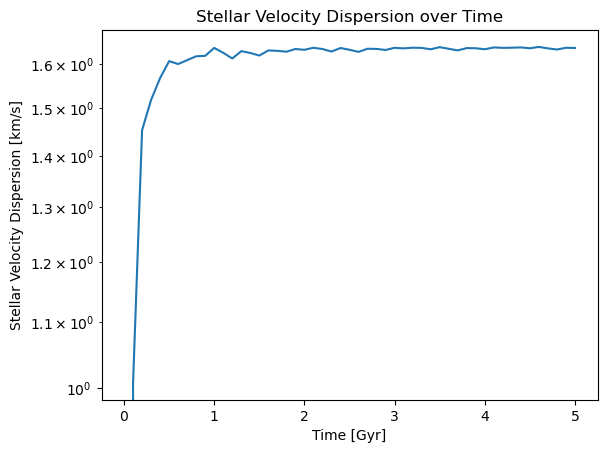

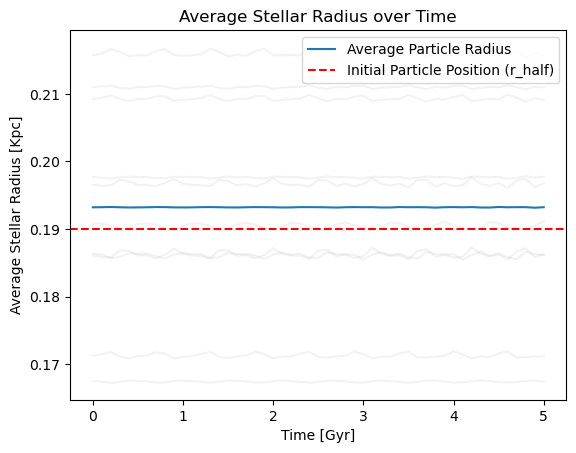

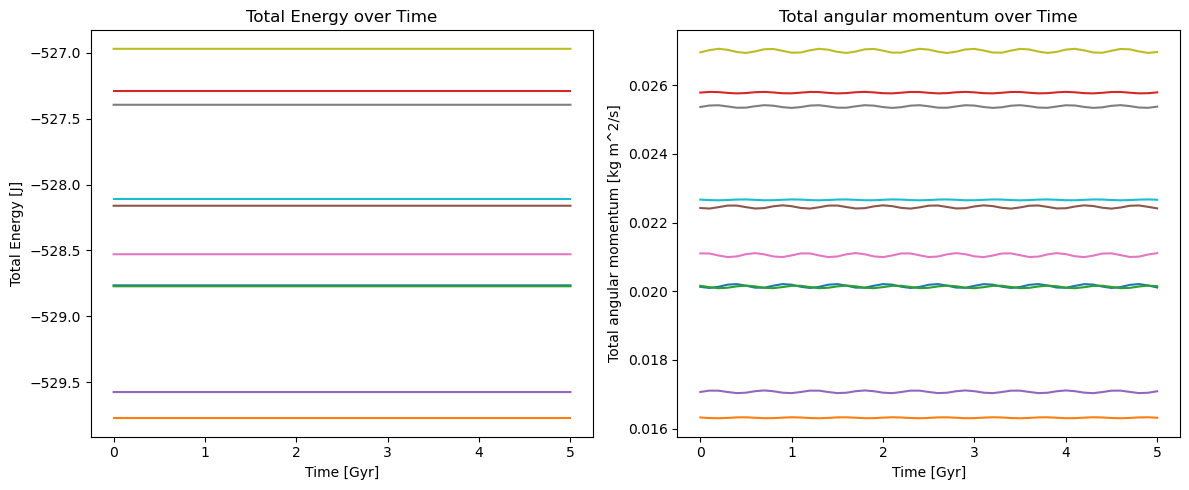

In [34]:
time_step2 = frozen_test_analytic.time_step
stellar_v_disp2 = np.mean(v_disp_all, axis=0)  # Average over particles

average_r2 = np.mean(r_all, axis=0)  # Average over particles


x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, stellar_v_disp2 * frozen_test_analytic.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, average_r2 * frozen_test_analytic.u.to_Kpc, label='Average Particle Radius')
for particle in range(r_all.shape[0]):
    plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, r_all[particle] * frozen_test_analytic.u.to_Kpc, alpha = 0.1, color='gray')
plt.axhline(frozen_test_analytic.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for particle in range(ang_mom_all.shape[0]):
    ax[0].plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, (kinetic_energy_all[particle] + potential_energy_all[particle]), label='Total Energy')
ax[0].set_xlabel('Time [Gyr]')
ax[0].set_ylabel('Total Energy [J]')
ax[0].set_title('Total Energy over Time')




for particle in range(ang_mom_all.shape[0]):
    ax[1].plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, ang_mom_all[particle], label='Total angular momentum')
ax[1].set_xlabel('Time [Gyr]')
ax[1].set_ylabel('Total angular momentum [kg m^2/s]')
ax[1].set_title('Total angular momentum over Time')


plt.tight_layout()
plt.show()




# 4) Frozen ULDM with leapfrog - 1000 timesteps

In [17]:

import importlib
importlib.reload(ATG)


animate = False
static = False
frozen = True
SphHT = False
integrator = 'leapfrog'

frozen_test_analytic = ATG.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 10, no_time_steps = 1000, total_evolve_time = 5, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, static = static, frozen = frozen, SphHT = SphHT, integrator = integrator, animate=animate, animate_every=10)

[CudaDevice(id=0)]
[CudaDevice(id=0)]


In [18]:

frozen_test_analytic.run_simulation()

l max from jaxsp: 23
Total enclosed mass at rmax: 6.640e+02
Total mass from wavefunction: 7.164e+02
Scaling density and mass by factor 1.0789432781125217 to match total mass
Particle 0: v_circ = [0.82145753 2.50316994 0.25725592] km/s
Particle 1: v_circ = [ 0.71806366 -2.28271509  1.13156051] km/s
Particle 2: v_circ = [-0.12241866 -1.6850446  -2.03776132] km/s
Particle 3: v_circ = [ 1.15833258 -0.66112686 -2.28648414] km/s
Particle 4: v_circ = [ 2.13708763 -1.248559   -0.93850396] km/s
Particle 5: v_circ = [-1.03460478 -1.93395851 -1.48196836] km/s
Particle 6: v_circ = [ 1.05624884 -0.45886201 -2.38340447] km/s
Particle 7: v_circ = [ 1.95127204  1.44454823 -1.05482257] km/s
Particle 8: v_circ = [ 0.14209196  1.57616312 -2.12187476] km/s
Particle 9: v_circ = [ 2.59793178 -0.28751994 -0.41822908] km/s
Loading Gaunt table from gaunt_lmax23_Lout47.npz ...
New initial circular velocity at r_half: [0.82618808 2.51758503 0.25873739] km/s
New initial circular velocity at r_half: [ 0.72302539 -

In [19]:
# Convert to numpy for plotting/analysis
import numpy as np

positions_all = np.array([p.positions_xyz for p in frozen_test_analytic.particles])  # (N_particles, N_steps+1, 3)
r_all         = np.array([p.r_values      for p in frozen_test_analytic.particles])  # (N_particles, N_steps+1)
v_disp_all    = np.array([p.stellar_v_disp for p in frozen_test_analytic.particles]) # (N_particles, N_steps+1)


(10, 1001, 3)


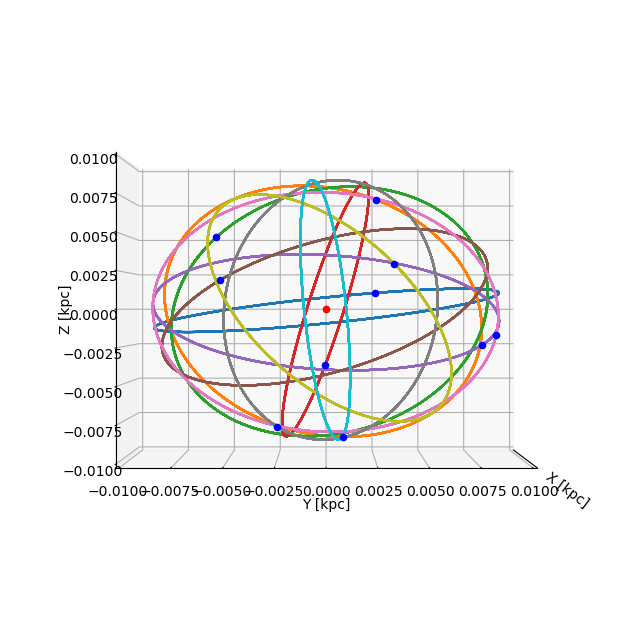

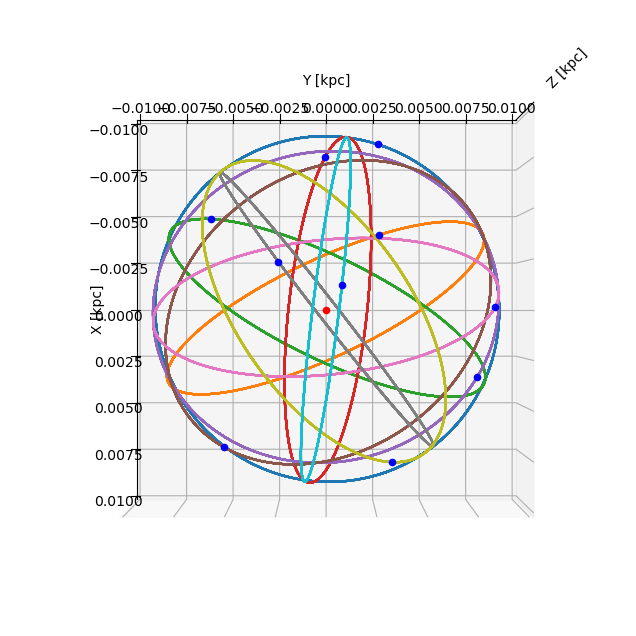

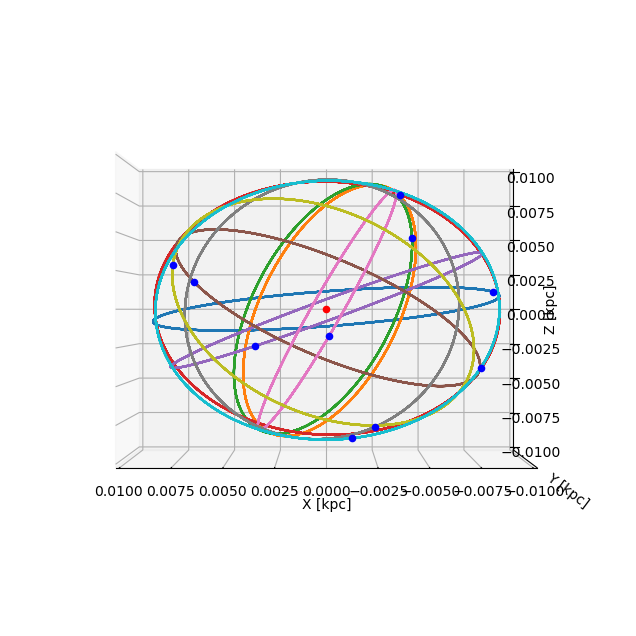

In [20]:

print(positions_all.shape)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')

for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
for i in range(positions_all.shape[0]):
    ax.scatter(positions_all[i, 0, 0], positions_all[i, 0, 1], positions_all[i, 0, 2], color='blue', label='Initial Position' if i == 0 else "")
    ax.plot(positions_all[i, :, 0], positions_all[i, :, 1], positions_all[i, :, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


In [21]:
if animate == True:
    ani = frozen_test_analytic.animator.create_animation()


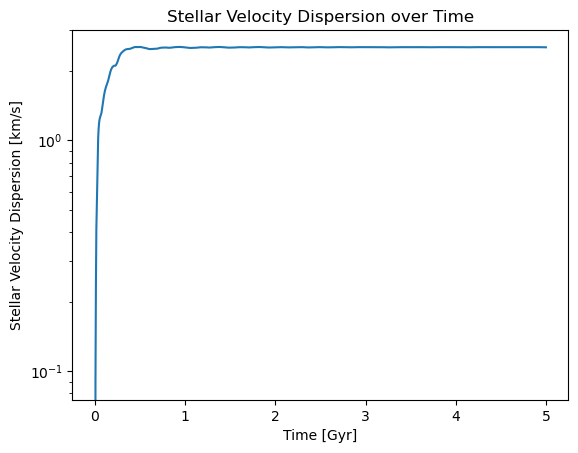

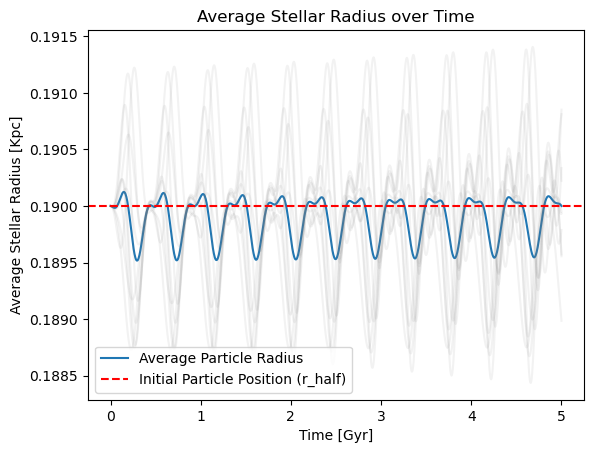

In [22]:
time_step2 = frozen_test_analytic.time_step
stellar_v_disp2 = np.mean(v_disp_all, axis=0)  # Average over particles

average_r2 = np.mean(r_all, axis=0)  # Average over particles


x = np.linspace(0, time_step2, len(stellar_v_disp2))

plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, stellar_v_disp2 * frozen_test_analytic.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, average_r2 * frozen_test_analytic.u.to_Kpc, label='Average Particle Radius')
for particle in range(r_all.shape[0]):
    plt.plot(x * frozen_test_analytic.dt * frozen_test_analytic.u.to_Gyr, r_all[particle] * frozen_test_analytic.u.to_Kpc, alpha = 0.1, color='gray')
plt.axhline(frozen_test_analytic.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()




# Testing the different methods of obtaining acceleration from density field

## 1) Static cNFWt Profile using Bessel

In [ ]:

import importlib
importlib.reload(BT)


animate = False
static = True
frozen = False

cNFWt_test = BT.StellarSimTDep(m22 = 1, r_half = 0.19, no_of_particles = 1, no_time_steps = 1000, total_evolve_time = 5, r_min = 20, 
                               r_max_enclosing_frac = 0.99, no_radius_bins = 1000, N_max = 1000, static = static, frozen = frozen, animate=animate, animate_every=10)

[CudaDevice(id=0)]


l max from jaxsp: 23
Forward s2fft completed in 0.01 seconds


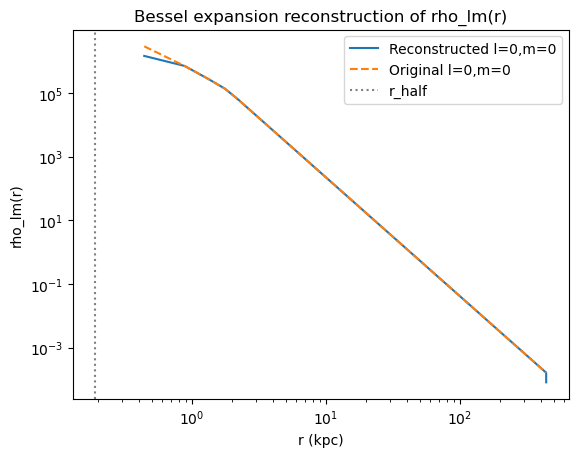

Conversion from rho_lm(r) to rho_nlm completed in 1.65 seconds
Time step 2 / 1000
Time stepping particle completed in 3.19 seconds
Time step 3 / 1000
Time stepping particle completed in 3.53 seconds
Time step 4 / 1000
Time stepping particle completed in 3.34 seconds
Time step 5 / 1000
Time stepping particle completed in 3.26 seconds
Time step 6 / 1000
Time stepping particle completed in 3.40 seconds
Time step 7 / 1000
Time stepping particle completed in 3.40 seconds
Time step 8 / 1000
Time stepping particle completed in 3.07 seconds
Time step 9 / 1000
Time stepping particle completed in 3.89 seconds
Time step 10 / 1000
Time stepping particle completed in 3.19 seconds
Time step 11 / 1000
Time stepping particle completed in 3.08 seconds
Time step 12 / 1000
Time stepping particle completed in 3.44 seconds
Time step 13 / 1000
Time stepping particle completed in 3.05 seconds
Time step 14 / 1000
Time stepping particle completed in 3.38 seconds
Time step 15 / 1000
Time stepping particle compl

KeyboardInterrupt: 

In [ ]:
cNFWt_test.run_simulation()

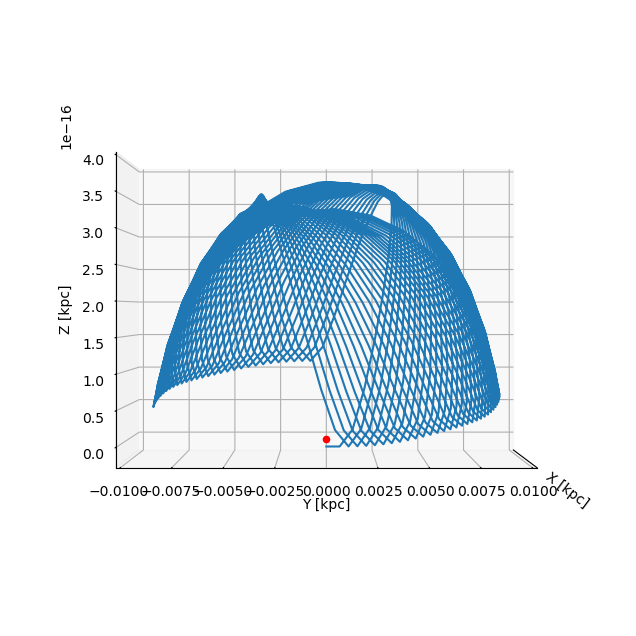

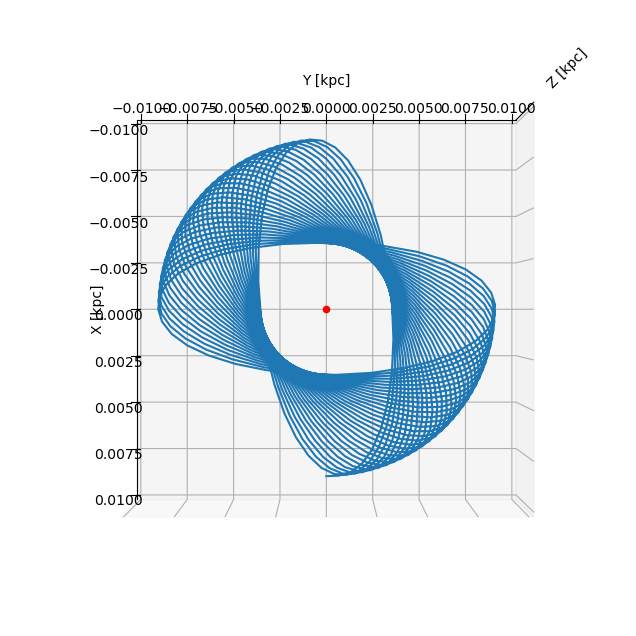

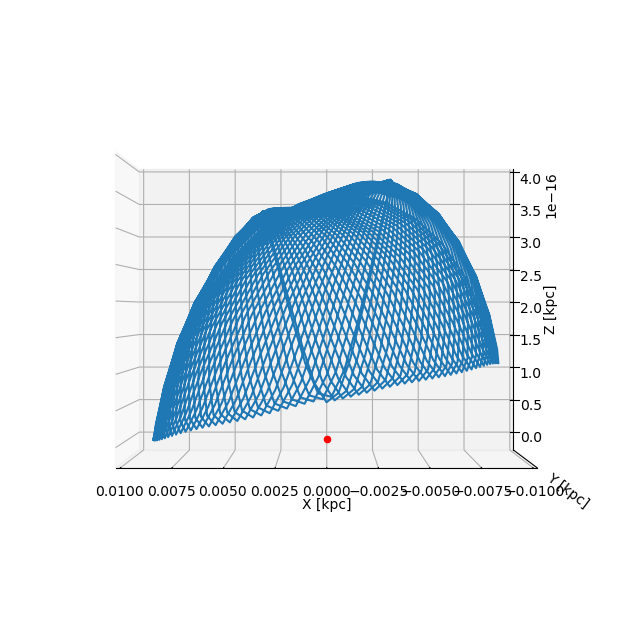

In [ ]:
pos = np.array(cNFWt_test.positions_xyz)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_xticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=90, azim=0)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_zticks([])
plt.show()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(0, 0, 0, color='red', label='Galactic Center')
ax.plot(pos[:, 0], pos[:, 1], pos[:, 2])
ax.view_init(elev=0, azim=90)
ax.set_xlabel('X [kpc]')
ax.set_ylabel('Y [kpc]')
ax.set_zlabel('Z [kpc]')
ax.set_yticks([])
plt.show()


KeyboardInterrupt: 

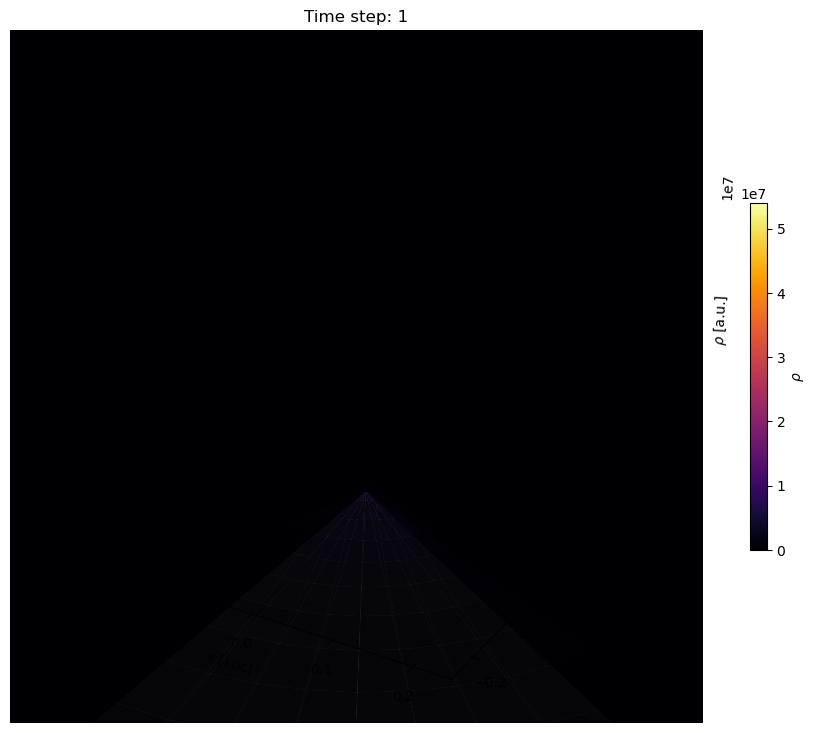

In [ ]:
if animate == True:
    ani = cNFWt_test.animator.create_animation()


In [ ]:

velocities = np.array(cNFWt_test.velocities)
stellar_v_disp = np.array(cNFWt_test.stellar_v_disp) 
average_r = np.array(cNFWt_test.average_r)
r_values = np.array(cNFWt_test.r_values)
time_step = cNFWt_test.time_step

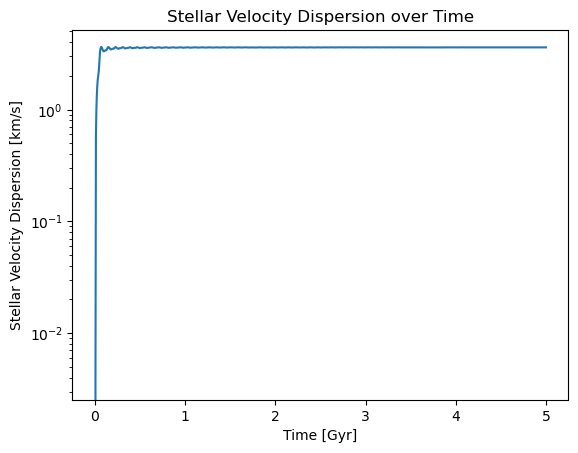

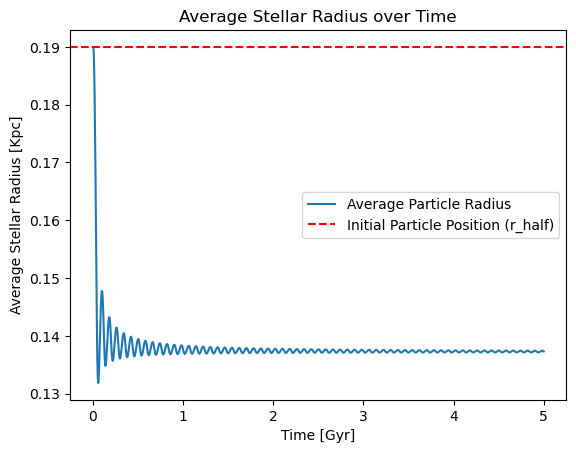

In [ ]:


x = np.linspace(0, time_step, len(stellar_v_disp))

plt.plot(x * cNFWt_test.dt * cNFWt_test.u.to_Gyr, stellar_v_disp * cNFWt_test.u.to_kms)
plt.yscale('log')
plt.xlabel('Time [Gyr]')
plt.ylabel('Stellar Velocity Dispersion [km/s]')
plt.title('Stellar Velocity Dispersion over Time')
plt.show()

plt.plot(x * cNFWt_test.dt * cNFWt_test.u.to_Gyr, average_r * cNFWt_test.u.to_Kpc, label='Average Particle Radius')
#plt.plot(x * first_sim.dt * first_sim.u.to_Gyr, r_values * first_sim.u.to_Kpc, label='Particle radial position')
plt.axhline(cNFWt_test.r_half, color='r', linestyle='--', label='Initial Particle Position (r_half)')
plt.xlabel('Time [Gyr]')
plt.ylabel('Average Stellar Radius [Kpc]')
plt.title('Average Stellar Radius over Time')
plt.legend()
plt.show()